In [1]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt 
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import sys
sys.path.append('../../DataSource/baostock')
import datasource

In [2]:
# 取得所有的额股票代码
codes = datasource.get_codes()

我要先取得上证指数，然后取得上海交易所的所有股票，然后遍历所有股票，依次的遍历，

In [23]:
dtsh_000001 = datasource.get_data('sh.000001')
dtsh_000001.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
date,,,,,,,,,,,,,
2010-01-04,sh.000001,3289.750,3295.279,3243.319,3243.760,3277.139,10944792700,1.337735e+11,3,0.009476,1,-1.018538,0
2010-01-05,sh.000001,3254.468,3290.512,3221.462,3282.179,3243.760,12611506600,1.618582e+11,3,0.010918,1,1.184395,0
2010-01-06,sh.000001,3277.517,3295.868,3253.044,3254.215,3282.179,12365138400,1.580401e+11,3,0.010705,1,-0.851991,0
2010-01-07,sh.000001,3253.991,3268.819,3176.707,3192.776,3254.215,12865282700,1.572296e+11,3,0.011138,1,-1.887988,0
2010-01-08,sh.000001,3177.259,3198.920,3149.017,3195.997,3192.776,9837714700,1.217399e+11,3,0.008516,1,0.100890,0


In [24]:
lst_sh = [i for i in codes if i.startswith('sh')]

In [25]:
# 我这里滋事取得每一个股票的相关数据,
# 这里用涨的数量，跌的数量来判断。
dtsh_000001['up_count'] = 0
dtsh_000001['down_count'] = 0
dtsh_000001.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,up_count,down_count
date,,,,,,,,,,,,,,,
2010-01-04,sh.000001,3289.750,3295.279,3243.319,3243.760,3277.139,10944792700,1.337735e+11,3,0.009476,1,-1.018538,0,0,0
2010-01-05,sh.000001,3254.468,3290.512,3221.462,3282.179,3243.760,12611506600,1.618582e+11,3,0.010918,1,1.184395,0,0,0
2010-01-06,sh.000001,3277.517,3295.868,3253.044,3254.215,3282.179,12365138400,1.580401e+11,3,0.010705,1,-0.851991,0,0,0
2010-01-07,sh.000001,3253.991,3268.819,3176.707,3192.776,3254.215,12865282700,1.572296e+11,3,0.011138,1,-1.887988,0,0,0
2010-01-08,sh.000001,3177.259,3198.920,3149.017,3195.997,3192.776,9837714700,1.217399e+11,3,0.008516,1,0.100890,0,0,0


In [26]:
_code_name = codes[0]
dt = datasource.get_data(_code_name)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
date,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0


In [27]:
# 我这里用pandas的方式去解决，不然，用手动遍历的方式太慢了
dt['up_down'] = dt['close'] - dt['preclose'] # 先取得涨跌了多少
dt['up_count2'] = dt.apply(lambda x:1 if x['up_down'] > 0 else 0, axis=1)
dt['down_count2'] = dt.apply(lambda x:1 if x['up_down'] <= 0 else 0, axis=1)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,up_down,up_count2,down_count2
date,,,,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0,-0.116332,0,1
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0,0.037226,1,0
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0,-0.097719,0,1
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0,-0.109352,0,1
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0,0.053513,1,0


In [28]:
dtsh_000001['up_count'] = dtsh_000001['up_count'] + dt['up_count2']
dtsh_000001['down_count'] = dtsh_000001['down_count'] + dt['down_count2']
dtsh_000001.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,up_count,down_count
date,,,,,,,,,,,,,,,
2010-01-04,sh.000001,3289.750,3295.279,3243.319,3243.760,3277.139,10944792700,1.337735e+11,3,0.009476,1,-1.018538,0,0,1
2010-01-05,sh.000001,3254.468,3290.512,3221.462,3282.179,3243.760,12611506600,1.618582e+11,3,0.010918,1,1.184395,0,1,0
2010-01-06,sh.000001,3277.517,3295.868,3253.044,3254.215,3282.179,12365138400,1.580401e+11,3,0.010705,1,-0.851991,0,0,1
2010-01-07,sh.000001,3253.991,3268.819,3176.707,3192.776,3254.215,12865282700,1.572296e+11,3,0.011138,1,-1.887988,0,0,1
2010-01-08,sh.000001,3177.259,3198.920,3149.017,3195.997,3192.776,9837714700,1.217399e+11,3,0.008516,1,0.100890,0,1,0


In [31]:
# 初始化
dtsh_000001['up_count'] = 0
dtsh_000001['down_count'] = 0

for i  in tqdm(range(len(codes))):
    _code_name = codes[i]
    # 先读取数据,
    dt = datasource.get_data(_code_name)
    dt['up_down'] = dt['close'] - dt['open'] # 收盘价减去开盘价，看看
    # 然后是看看是放在上升还是下降中
    dt['up_count2'] = dt.apply(lambda x:1 if x['up_down'] > 0 and x['isST'] == 0 else 0, axis=1)
    dt['down_count2'] = dt.apply(lambda x:1 if x['up_down'] <= 0 and x['isST'] == 0 else 0, axis=1)
    # 指数运算，.reindex(df1.index).fillna(0)是重建索引，且是根据指数的，这样是可以设置空值，然后再填充空值
    dtsh_000001['up_count'] = dtsh_000001['up_count'] +dt['up_count2'].reindex(dtsh_000001.index).fillna(0)
    dtsh_000001['down_count'] = dtsh_000001['down_count'] + dt['down_count2'].reindex(dtsh_000001.index).fillna(0)
    # 继续运算的话，up_count2,down_count2是重新被运算。
    
dtsh_000001.head()  

100%|██████████████████████████████████████████████████████████████████████████████| 5462/5462 [06:40<00:00, 13.64it/s]


,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,up_count,down_count,rate
date,,,,,,,,,,,,,,,,
2010-01-04,sh.000001,3289.750,3295.279,3243.319,3243.760,3277.139,10944792700,1.337735e+11,3,0.009476,1,-1.018538,0,569.0,972.0,-1.018541
2010-01-05,sh.000001,3254.468,3290.512,3221.462,3282.179,3243.760,12611506600,1.618582e+11,3,0.010918,1,1.184395,0,966.0,575.0,1.184397
2010-01-06,sh.000001,3277.517,3295.868,3253.044,3254.215,3282.179,12365138400,1.580401e+11,3,0.010705,1,-0.851991,0,630.0,914.0,-0.851995
2010-01-07,sh.000001,3253.991,3268.819,3176.707,3192.776,3254.215,12865282700,1.572296e+11,3,0.011138,1,-1.887988,0,231.0,1314.0,-1.887982
2010-01-08,sh.000001,3177.259,3198.920,3149.017,3195.997,3192.776,9837714700,1.217399e+11,3,0.008516,1,0.100890,0,1199.0,352.0,0.100884


In [33]:
# 看起来速度快很多，然后这里要看看指数的升降比了
dtsh_000001['rate'] = (dtsh_000001['close']-dtsh_000001['preclose'])/dtsh_000001['preclose']*100
dtsh_000001['rate2'] = dtsh_000001['up_count'] / ( dtsh_000001['up_count'] +  dtsh_000001['down_count'])*100
dtsh_000001.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,up_count,down_count,rate,rate2
date,,,,,,,,,,,,,,,,,
2010-01-04,sh.000001,3289.750,3295.279,3243.319,3243.760,3277.139,10944792700,1.337735e+11,3,0.009476,1,-1.018538,0,569.0,972.0,-1.018541,36.924075
2010-01-05,sh.000001,3254.468,3290.512,3221.462,3282.179,3243.760,12611506600,1.618582e+11,3,0.010918,1,1.184395,0,966.0,575.0,1.184397,62.686567
2010-01-06,sh.000001,3277.517,3295.868,3253.044,3254.215,3282.179,12365138400,1.580401e+11,3,0.010705,1,-0.851991,0,630.0,914.0,-0.851995,40.803109
2010-01-07,sh.000001,3253.991,3268.819,3176.707,3192.776,3254.215,12865282700,1.572296e+11,3,0.011138,1,-1.887988,0,231.0,1314.0,-1.887982,14.951456
2010-01-08,sh.000001,3177.259,3198.920,3149.017,3195.997,3192.776,9837714700,1.217399e+11,3,0.008516,1,0.100890,0,1199.0,352.0,0.100884,77.304965


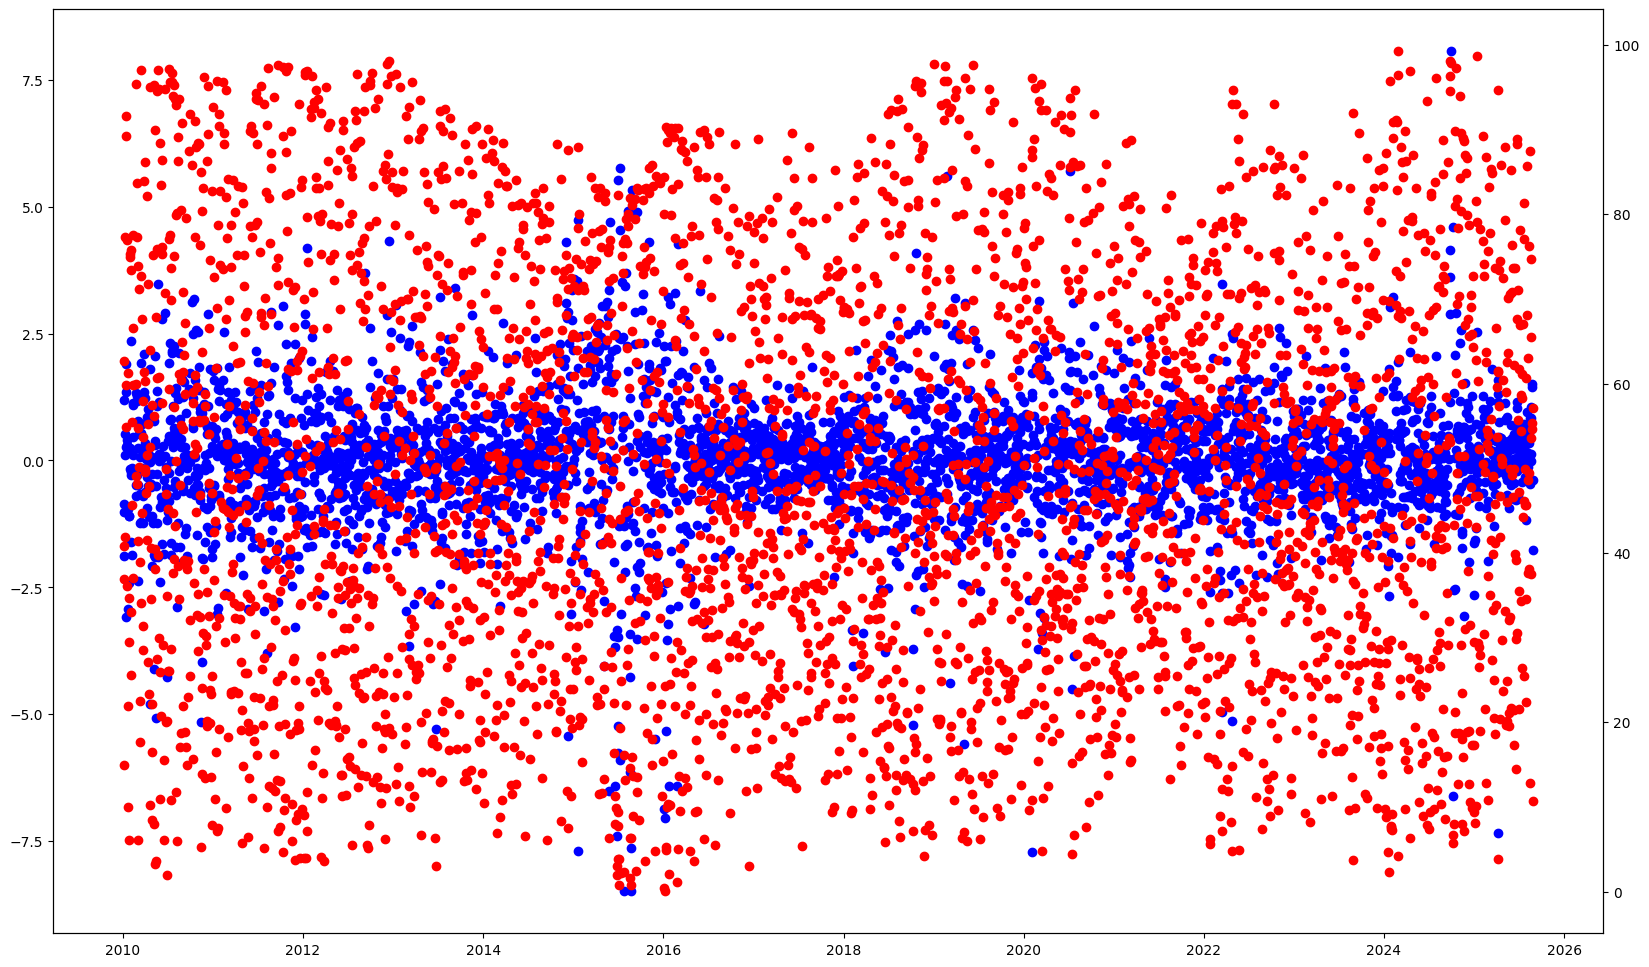

In [37]:
_x = dtsh_000001.index
_y1 = dtsh_000001['rate']
_y2 = dtsh_000001['rate2']
# 创建主图及左侧 Y 轴
fig, ax1 = plt.subplots(figsize=(20, 12))
# ax1.plot(_x, _y1, 'b-', label='close')
ax1.scatter(_x, _y1, c='blue', label='rate')
# 添加右侧 Y 轴
ax2 = ax1.twinx()
ax2.scatter(_x, _y2, c='red', label='rate2')

In [35]:
# 这里导出
dtsh_000001.to_csv('关系.csv', encoding='utf_8_sig')